In [2]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

warnings.filterwarnings("ignore")

np.random.seed(42)
tf.random.set_seed(42)

print("Libraries Imported Successfully.")

Libraries Imported Successfully.


In [3]:
ckd = pd.read_csv("../data/ckd.csv")

print("Dataset Shape:", ckd.shape)

ckd.head()

Dataset Shape: (400, 25)


,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane,class
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,...,44.0,7800.0,5.2,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,...,38.0,6000.0,NaN,no,no,no,good,no,no,ckd
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,...,31.0,7500.0,NaN,no,yes,no,poor,no,yes,ckd
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,...,32.0,6700.0,3.9,yes,no,no,poor,yes,yes,ckd
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,...,35.0,7300.0,4.6,no,no,no,good,no,no,ckd


In [4]:
ckd.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     391 non-null    float64
 1   bp      388 non-null    float64
 2   sg      353 non-null    float64
 3   al      354 non-null    float64
 4   su      351 non-null    float64
 5   rbc     248 non-null    str    
 6   pc      335 non-null    str    
 7   pcc     396 non-null    str    
 8   ba      396 non-null    str    
 9   bgr     356 non-null    float64
 10  bu      381 non-null    float64
 11  sc      383 non-null    float64
 12  sod     313 non-null    float64
 13  pot     312 non-null    float64
 14  hemo    348 non-null    float64
 15  pcv     329 non-null    float64
 16  wbcc    294 non-null    float64
 17  rbcc    269 non-null    float64
 18  htn     398 non-null    str    
 19  dm      398 non-null    str    
 20  cad     398 non-null    str    
 21  appet   399 non-null    str    
 22  pe      399 n

In [5]:
print(ckd.isnull().sum())

age        9
bp        12
sg        47
al        46
su        49
rbc      152
pc        65
pcc        4
ba         4
bgr       44
bu        19
sc        17
sod       87
pot       88
hemo      52
pcv       71
wbcc     106
rbcc     131
htn        2
dm         2
cad        2
appet      1
pe         1
ane        1
class      0
dtype: int64


In [6]:
ckd = ckd.replace("?", np.nan)

print("Missing values converted.")

Missing values converted.


In [7]:
numeric_cols = [
    "age",
    "bp",
    "sg",
    "al",
    "su",
    "bgr",
    "bu",
    "sc",
    "sod",
    "pot",
    "hemo",
    "pcv",
    "wbcc",
    "rbcc"
]

for col in numeric_cols:
    ckd[col] = pd.to_numeric(
        ckd[col],
        errors="coerce"
    )

print("Numeric conversion completed.")

Numeric conversion completed.


In [8]:
for col in numeric_cols:
    ckd[col] = ckd[col].fillna(
        ckd[col].median()
    )

categorical_cols = [
    col for col in ckd.columns
    if col not in numeric_cols
]

for col in categorical_cols:
    ckd[col] = ckd[col].fillna(
        ckd[col].mode()[0]
    )

print("Missing values filled.")

Missing values filled.


In [9]:
encoder = LabelEncoder()

cat_cols = ckd.select_dtypes(
    include=["object"]
).columns

for col in cat_cols:
    ckd[col] = encoder.fit_transform(
        ckd[col]
    )

print("Encoding completed.")

ckd.head()

Encoding completed.


,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane,class
0,48.0,80.0,1.020,1.0,0.0,1,1,0,0,121.0,...,44.0,7800.0,5.2,1,1,0,0,0,0,0
1,7.0,50.0,1.020,4.0,0.0,1,1,0,0,121.0,...,38.0,6000.0,4.8,0,0,0,0,0,0,0
2,62.0,80.0,1.010,2.0,3.0,1,1,0,0,423.0,...,31.0,7500.0,4.8,0,1,0,1,0,1,0
3,48.0,70.0,1.005,4.0,0.0,1,0,1,0,117.0,...,32.0,6700.0,3.9,1,0,0,1,1,1,0
4,51.0,80.0,1.010,2.0,0.0,1,1,0,0,106.0,...,35.0,7300.0,4.6,0,0,0,0,0,0,0


In [10]:
X = ckd.drop("class", axis=1)

y = ckd["class"]

print("Features Shape :", X.shape)

print("Target Shape :", y.shape)

Features Shape : (400, 24)
Target Shape : (400,)


In [11]:
scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(X)

print("Normalization completed.")

Normalization completed.


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Samples :", X_train.shape)

print("Testing Samples :", X_test.shape)

Training Samples : (320, 24)
Testing Samples : (80, 24)


In [15]:
model = Sequential([
    Dense(64, activation="relu", input_shape=(X_train.shape[1],)),
    Dropout(0.30),
    Dense(32, activation="relu"),
    Dropout(0.30),
    Dense(16, activation="relu"),
    Dense(1, activation="sigmoid")

])
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │         1,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,225 (16.50 KB)

 Trainable params: 4,225 (16.50 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.20,
    epochs=50,
    batch_size=32,
    verbose=1
)
print("Model Training Completed Successfully.")

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 95ms/step - accuracy: 0.5234 - loss: 0.6900 - val_accuracy: 0.6562 - val_loss: 0.6521
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.6211 - loss: 0.6527 - val_accuracy: 0.6562 - val_loss: 0.6138
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.6484 - loss: 0.6187 - val_accuracy: 0.6562 - val_loss: 0.5747
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.6680 - loss: 0.5658 - val_accuracy: 0.6562 - val_loss: 0.5263
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.6953 - loss: 0.5323 - val_accuracy: 0.7031 - val_loss: 0.4657
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.7734 - loss: 0.4702 - val_accuracy: 1.0000 - val_loss: 0.4045
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8438 - loss: 0.4066 - val_accuracy: 0.9688 - val_loss: 0.3434
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9180 - loss: 0.3526 - val_accuracy: 0.9219 - val_loss: 0.2900


In [17]:
y_prob = model.predict(X_test)
y_pred = (y_prob > 0.5).astype(int).flatten()

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


In [18]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
print("="*50)
print("Generalization Test Results")
print("="*50)
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC AUC  : {roc_auc:.4f}")

Generalization Test Results
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1 Score : 1.0000
ROC AUC  : 1.0000


In [19]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       1.00      1.00      1.00        30

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



In [20]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[50  0]
 [ 0 30]]


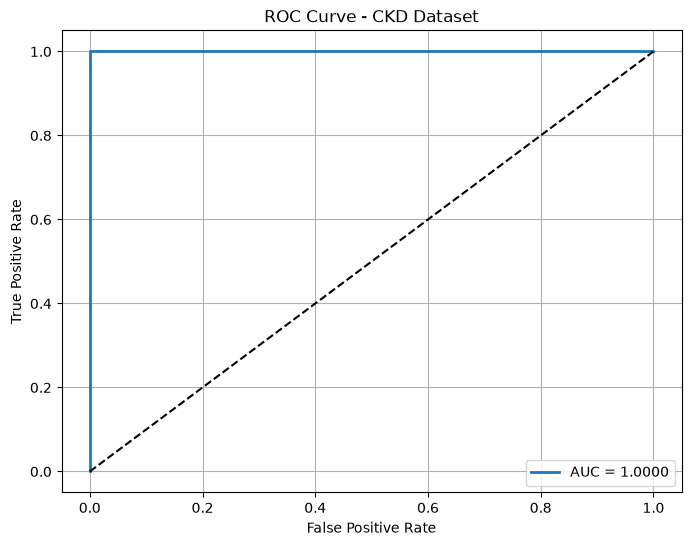

ROC curve saved successfully.


In [30]:
fpr, tpr, threshold = roc_curve(y_test, y_prob)

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, linewidth=2, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1],[0,1],"k--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - CKD Dataset")

plt.legend()
plt.grid(True)

plt.savefig(
    "../results/roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("ROC curve saved successfully.")

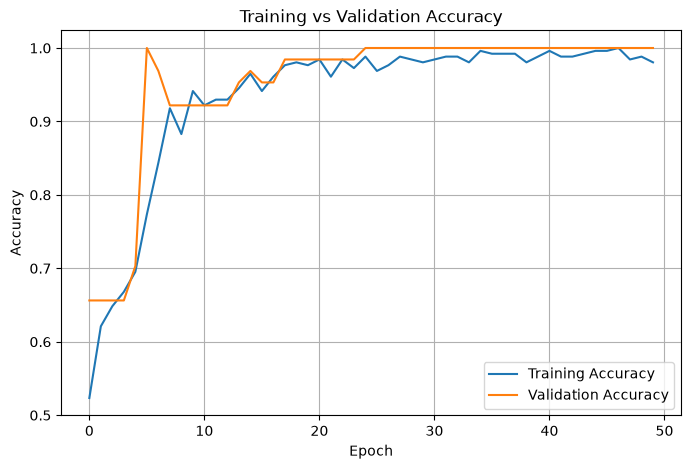

Training Accuracy graph saved successfully.


In [31]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend()
plt.grid(True)

plt.savefig(
    "../results/training_validation_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Training Accuracy graph saved successfully.")

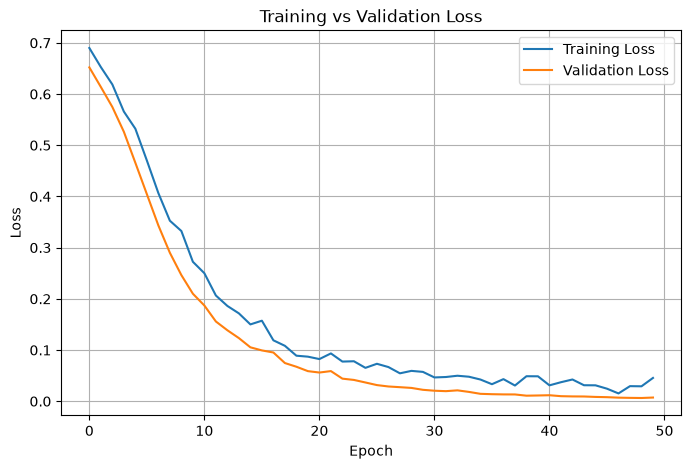

Training Loss graph saved successfully.


In [32]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.grid(True)

plt.savefig(
    "../results/training_validation_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Training Loss graph saved successfully.")

In [23]:
predictions = pd.DataFrame(X_test, columns=X.columns)

predictions["Actual"] = y_test.values
predictions["Predicted"] = y_pred
predictions["Probability"] = y_prob.flatten()

predictions.head()

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,rbcc,htn,dm,cad,appet,pe,ane,Actual,Predicted,Probability
0,0.897727,0.076923,0.75,0.0,0.0,1.0,1.0,0.0,0.0,0.269231,...,0.050847,1.0,1.0,1.0,1.0,1.0,0.0,0,0,3.622479e-12
1,0.670455,0.230769,0.50,0.4,0.0,0.0,0.0,0.0,0.0,0.322650,...,0.186441,1.0,1.0,1.0,1.0,1.0,1.0,0,0,1.571589e-15
2,0.625000,0.230769,0.75,0.0,0.0,1.0,1.0,0.0,0.0,0.237179,...,0.576271,0.0,0.0,0.0,0.0,0.0,0.0,1,1,9.720345e-01
3,0.602273,0.153846,0.75,0.0,0.0,1.0,1.0,0.0,0.0,0.181624,...,0.677966,0.0,0.0,0.0,0.0,0.0,0.0,1,1,9.949533e-01
4,0.261364,0.153846,0.75,0.0,0.0,1.0,1.0,0.0,0.0,0.141026,...,0.474576,0.0,0.0,0.0,0.0,0.0,0.0,1,1,9.830536e-01


In [24]:
false_negatives = predictions[
    (predictions["Actual"] == 1) &
    (predictions["Predicted"] == 0)
]

print("False Negatives :", len(false_negatives))

false_negatives

False Negatives : 0


,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,rbcc,htn,dm,cad,appet,pe,ane,Actual,Predicted,Probability


In [25]:
false_positives = predictions[
    (predictions["Actual"] == 0) &
    (predictions["Predicted"] == 1)
]

print("False Positives :", len(false_positives))

false_positives

False Positives : 0


,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,rbcc,htn,dm,cad,appet,pe,ane,Actual,Predicted,Probability


In [26]:
false_negatives.to_csv(
    "../results/false_negatives.csv",
    index=False
)

false_positives.to_csv(
    "../results/false_positives.csv",
    index=False
)

print("Error files saved successfully.")

Error files saved successfully.


In [27]:
summary = pd.DataFrame({

    "Metric":[
        "False Negatives",
        "False Positives",
        "Total Test Samples"
    ],

    "Value":[
        len(false_negatives),
        len(false_positives),
        len(predictions)
    ]

})

summary

,Metric,Value
0,False Negatives,0
1,False Positives,0
2,Total Test Samples,80


In [28]:
summary.to_csv(
    "../results/error_summary.csv",
    index=False
)

print("Summary saved successfully.")

Summary saved successfully.


In [29]:
if len(false_negatives) > 0:
    print(false_negatives.describe())
else:
    print("No False Negatives found.")

if len(false_positives) > 0:
    print(false_positives.describe())
else:
    print("No False Positives found.")

No False Negatives found.
No False Positives found.
